# CVRP Fisher-Jaikumar GAP + TSP VQE Workflow

This notebook implements a Fisher-Jaikumar style cluster-first, route-second decomposition for a small CVRP instance. The clustering stage is reduced to a Generalized Assignment Problem (GAP), converted to a QUBO with a selectable capacity penalty, and solved with local VQE. The decoded clusters are then routed as TSP subproblems.

The notebook defaults to the synthetic `Toy-n7-k2` instance so the local matrix-product-state VQE path stays small. The route-stage TSPs can be solved exactly classically or converted to QUBOs and solved with VQE as well.


## Method summary

Fisher-Jaikumar decomposition uses two optimization stages:

1. Pick one seed customer per vehicle.
2. Build a GAP that assigns every customer to exactly one vehicle while controlling vehicle capacity. The assignment cost for customer `i` and vehicle seed `s_k` is the insertion-style cost `d(0, i) + d(i, s_k) - d(0, s_k)`, where `0` is the depot.
3. Convert the selected GAP formulation to QUBO and solve it with local VQE.
4. Decode the GAP bitstring into vehicle clusters.
5. Route each vehicle cluster as a TSP, using either classical exact enumeration or route-level VQE.

For the toy instance, the selected no-slack GAP penalty gives a 12-qubit VQE problem, and each capacity-feasible route TSP is at most 9 qubits.


## Why this uses fewer qubits

The full arc-MTZ CVRP formulation estimated earlier was about 4320 binary variables for the larger XSH instance. Fisher-Jaikumar splits the problem into smaller pieces:

- GAP clustering: `customers * vehicles` assignment variables.
- Route-second TSP: after GAP produces a cluster with `r` customers, the route QUBO uses `r * r` position-assignment variables.

This notebook now defaults to `Toy-n7-k2`, a synthetic 6-customer, 2-vehicle instance that is small enough for quantum simulation experiments. For this instance, the GAP has `6 * 2 = 12` assignment variables. A direct hard-capacity GAP QUBO uses slack bits for the two capacity inequalities; with capacity `9`, that is `ceil(log2(9 + 1)) = 4` slack bits per vehicle, so the hard-capacity GAP QUBO is `12 + 2 * 4 = 20` variables.

The Taylor and tilted penalty variants bake the capacity inequality into the GAP objective, so they avoid capacity slack variables and keep the GAP QUBO at `12` variables. For a capacity-feasible clustering in this toy instance, no route can contain more than 3 customers, so each route-second TSP QUBO is at most `3 * 3 = 9` variables.

You can still switch `INSTANCE_NAME` back to `E-n13-k4.vrp` or an XSH instance when you only want QUBO construction and qubit-count comparisons.


In [48]:
from itertools import combinations, permutations
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from qiskit.circuit.library import efficient_su2
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

backend = AerSimulator(method='matrix_product_state', seed_simulator=7)
estimator = BackendEstimatorV2(backend=backend)
sampler = BackendSamplerV2(backend=backend)


In [49]:
def find_cvrp_dir():
    candidates = [
        Path('cvrp'),
        Path('individual') / 'cvrp',
        Path.cwd() / 'cvrp',
        Path.cwd() / 'individual' / 'cvrp',
    ]
    for candidate in candidates:
        if candidate.exists() and any(candidate.glob('*.vrp')):
            return candidate
    raise FileNotFoundError('Could not find a cvrp folder containing .vrp files.')


def _build_explicit_distance_matrix(metadata, edge_weights):
    dimension = int(metadata['DIMENSION'])
    edge_format = metadata.get('EDGE_WEIGHT_FORMAT', '').strip()
    matrix = [[0 for _ in range(dimension)] for _ in range(dimension)]

    if edge_format == 'LOWER_ROW':
        expected = dimension * (dimension - 1) // 2
        if len(edge_weights) != expected:
            raise ValueError(f'LOWER_ROW expected {expected} weights, found {len(edge_weights)}')
        index = 0
        for row in range(1, dimension):
            for col in range(row):
                weight = edge_weights[index]
                index += 1
                matrix[row][col] = weight
                matrix[col][row] = weight
        return matrix

    if edge_format == 'FULL_MATRIX':
        expected = dimension * dimension
        if len(edge_weights) != expected:
            raise ValueError(f'FULL_MATRIX expected {expected} weights, found {len(edge_weights)}')
        for row in range(dimension):
            for col in range(dimension):
                matrix[row][col] = edge_weights[row * dimension + col]
        return matrix

    raise ValueError(f'Unsupported EDGE_WEIGHT_FORMAT: {edge_format}')


def read_cvrp_instance(file_path):
    file_path = Path(file_path)
    metadata = {}
    coords = {}
    demands = {}
    depots = []
    edge_weights = []
    section = None

    for raw_line in file_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line or line.startswith('#'):
            continue
        if line == 'EOF':
            break
        if line in {'NODE_COORD_SECTION', 'EDGE_WEIGHT_SECTION', 'DEMAND_SECTION', 'DEPOT_SECTION'}:
            section = line
            continue

        if section == 'NODE_COORD_SECTION':
            node, x_coord, y_coord = line.split()[:3]
            coords[int(node)] = (float(x_coord), float(y_coord))
            continue

        if section == 'EDGE_WEIGHT_SECTION':
            edge_weights.extend(int(value) for value in line.split())
            continue

        if section == 'DEMAND_SECTION':
            node, demand = line.split()[:2]
            demands[int(node)] = int(float(demand))
            continue

        if section == 'DEPOT_SECTION':
            node = int(line.split()[0])
            if node != -1:
                depots.append(node)
            continue

        if ':' in line:
            key, value = line.split(':', 1)
            metadata[key.strip()] = value.strip().strip('"')

    if not depots:
        raise ValueError(f'No depot found in {file_path}')

    dimension = int(metadata['DIMENSION'])
    distance_matrix = None
    if edge_weights:
        distance_matrix = _build_explicit_distance_matrix(metadata, edge_weights)
        nodes = list(range(1, dimension + 1))
    else:
        nodes = sorted(coords)
        if len(nodes) != dimension:
            raise ValueError(f'Expected {dimension} coordinate nodes, found {len(nodes)}')

    if set(demands) != set(nodes):
        raise ValueError('Demand section and node set have different node ids.')

    depot = depots[0]
    customers = [node for node in nodes if node != depot]
    return {
        'path': file_path,
        'metadata': metadata,
        'coords': coords,
        'demands': demands,
        'depots': depots,
        'depot': depot,
        'nodes': nodes,
        'customers': customers,
        'distance_matrix': distance_matrix,
    }


def parse_vehicle_count(instance, default=1):
    name = instance['metadata'].get('NAME', instance['path'].stem)
    match = re.search(r'-k(\d+)', name)
    return int(match.group(1)) if match else default


def euclidean_distance(instance, a, b):
    if instance.get('distance_matrix') is not None:
        return instance['distance_matrix'][a - 1][b - 1]

    ax, ay = instance['coords'][a]
    bx, by = instance['coords'][b]
    return int(round(math.hypot(ax - bx, ay - by)))


def print_instance_summary(instance):
    capacity = int(instance['metadata']['CAPACITY'])
    parsed_vehicles = parse_vehicle_count(instance, default=len(instance['customers']))
    total_demand = sum(instance['demands'][node] for node in instance['customers'])
    print(f"Instance: {instance['metadata'].get('NAME', instance['path'].stem)}")
    print(f"Comment: {instance['metadata'].get('COMMENT', '')}")
    print(f"Customers: {len(instance['customers'])}")
    print(f"Depot: {instance['depot']}")
    print(f"Parsed vehicles: {parsed_vehicles}")
    print(f"Capacity: {capacity}")
    print(f"Total demand: {total_demand}")
    print(f"Demand / capacity: {total_demand / capacity:.2f}")
    if instance.get('distance_matrix') is not None:
        print(f"Distance source: explicit {instance['metadata'].get('EDGE_WEIGHT_FORMAT', '').strip()} matrix")
    else:
        print('Distance source: Euclidean node coordinates')


In [50]:
INSTANCE_NAME = 'Toy-n7-k2.vrp'
CVRP_DIR = find_cvrp_dir()
instance = read_cvrp_instance(CVRP_DIR / INSTANCE_NAME)
parsed_vehicle_count = parse_vehicle_count(instance, default=len(instance['customers']))
vehicle_capacity = int(instance['metadata']['CAPACITY'])

print(f"CVRP directory: {CVRP_DIR.resolve()}")
print_instance_summary(instance)


CVRP directory: /Users/monitsharma/SMU-Quantum-Repos/autoqresearch/individual/cvrp
Instance: Toy-n7-k2
Comment: Synthetic 6-customer CVRP instance for small quantum simulation demos
Customers: 6
Depot: 1
Parsed vehicles: 2
Capacity: 9
Total demand: 18
Demand / capacity: 2.00
Distance source: Euclidean node coordinates


## Seed selection

Fisher-Jaikumar needs one seed customer per vehicle. The seed choice is a heuristic input to the GAP, not an optimization solve.

This notebook implements several seed rules and lets you pick one with `SEED_METHOD`:

- `angle_spread`: choose seeds near evenly spaced polar angles around the depot, anchored at the farthest customer.
- `sweep_sector`: split customers into angular sectors and choose the farthest customer in each sector.
- `farthest_first`: Gonzalez-style max-min dispersion from the depot and already selected seeds.
- `depot_farthest`: choose the customers farthest from the depot.
- `largest_demand`: choose high-demand customers first, using depot distance as a tie-breaker.
- `random`: reproducible random baseline using `SEED_RANDOM_STATE`.

The angle methods require coordinates. If you select one on an explicit-distance instance without coordinates, the notebook falls back to `farthest_first` and prints a message.


In [51]:
def _customer_radius(instance, customer):
    return euclidean_distance(instance, instance['depot'], customer)


def _customer_angle(instance, customer):
    depot = instance['depot']
    dx = instance['coords'][customer][0] - instance['coords'][depot][0]
    dy = instance['coords'][customer][1] - instance['coords'][depot][1]
    return math.atan2(dy, dx) % (2.0 * math.pi)


def _angular_distance(left, right):
    diff = abs((left - right) % (2.0 * math.pi))
    return min(diff, 2.0 * math.pi - diff)


def choose_farthest_first_seeds(instance, num_seeds):
    customers = instance['customers']
    depot = instance['depot']
    if num_seeds > len(customers):
        raise ValueError('Cannot choose more seeds than customers.')

    seeds = [max(customers, key=lambda customer: (euclidean_distance(instance, depot, customer), -customer))]
    while len(seeds) < num_seeds:
        remaining = [customer for customer in customers if customer not in seeds]
        next_seed = max(
            remaining,
            key=lambda customer: (
                min(euclidean_distance(instance, customer, seed) for seed in seeds),
                euclidean_distance(instance, depot, customer),
                -customer,
            ),
        )
        seeds.append(next_seed)
    return seeds


def choose_depot_farthest_seeds(instance, num_seeds):
    return sorted(
        instance['customers'],
        key=lambda customer: (_customer_radius(instance, customer), -customer),
        reverse=True,
    )[:num_seeds]


def choose_largest_demand_seeds(instance, num_seeds):
    return sorted(
        instance['customers'],
        key=lambda customer: (instance['demands'][customer], _customer_radius(instance, customer), -customer),
        reverse=True,
    )[:num_seeds]


def choose_angle_spread_seeds(instance, num_seeds):
    if not instance.get('coords'):
        raise ValueError('angle_spread requires NODE_COORD_SECTION coordinates.')

    customers = instance['customers']
    anchor = _customer_angle(
        instance,
        max(customers, key=lambda customer: (_customer_radius(instance, customer), -customer)),
    )
    targets = [(anchor + step * 2.0 * math.pi / num_seeds) % (2.0 * math.pi) for step in range(num_seeds)]
    seeds = []
    for target in targets:
        remaining = [customer for customer in customers if customer not in seeds]
        seed = min(
            remaining,
            key=lambda customer: (
                _angular_distance(_customer_angle(instance, customer), target),
                -_customer_radius(instance, customer),
                customer,
            ),
        )
        seeds.append(seed)
    return seeds


def choose_sweep_sector_seeds(instance, num_seeds):
    if not instance.get('coords'):
        raise ValueError('sweep_sector requires NODE_COORD_SECTION coordinates.')

    customers = instance['customers']
    anchor = _customer_angle(
        instance,
        max(customers, key=lambda customer: (_customer_radius(instance, customer), -customer)),
    )
    sector_width = 2.0 * math.pi / num_seeds
    seeds = []
    for sector in range(num_seeds):
        start = (anchor + sector * sector_width) % (2.0 * math.pi)
        sector_customers = []
        for customer in customers:
            shifted_angle = (_customer_angle(instance, customer) - start) % (2.0 * math.pi)
            if shifted_angle < sector_width:
                sector_customers.append(customer)
        remaining_sector_customers = [customer for customer in sector_customers if customer not in seeds]
        if remaining_sector_customers:
            seeds.append(max(remaining_sector_customers, key=lambda customer: (_customer_radius(instance, customer), -customer)))

    while len(seeds) < num_seeds:
        remaining = [customer for customer in customers if customer not in seeds]
        seeds.append(max(remaining, key=lambda customer: (_customer_radius(instance, customer), -customer)))
    return seeds[:num_seeds]


def choose_random_seeds(instance, num_seeds, random_state=7):
    rng = np.random.default_rng(random_state)
    return list(rng.choice(instance['customers'], size=num_seeds, replace=False))


SEED_METHOD_DESCRIPTIONS = {
    'angle_spread': 'evenly spaced polar angles around the depot',
    'sweep_sector': 'farthest customer in each angular sector',
    'farthest_first': 'max-min dispersion from depot and selected seeds',
    'depot_farthest': 'largest depot distance',
    'largest_demand': 'largest demand, tie-broken by depot distance',
    'random': 'reproducible random baseline',
}


SEED_METHODS = {
    'angle_spread': choose_angle_spread_seeds,
    'sweep_sector': choose_sweep_sector_seeds,
    'farthest_first': choose_farthest_first_seeds,
    'depot_farthest': choose_depot_farthest_seeds,
    'largest_demand': choose_largest_demand_seeds,
    'random': choose_random_seeds,
}


def choose_seed_customers(instance, num_seeds, method='angle_spread', random_state=7):
    if method not in SEED_METHODS:
        raise ValueError(f"Unknown seed method {method!r}. Choose from {sorted(SEED_METHODS)}")

    try:
        if method == 'random':
            return SEED_METHODS[method](instance, num_seeds, random_state=random_state), method
        return SEED_METHODS[method](instance, num_seeds), method
    except ValueError as exc:
        if method in {'angle_spread', 'sweep_sector'} and not instance.get('coords'):
            fallback = 'farthest_first'
            print(f"{method!r} needs coordinates; falling back to {fallback!r}. Detail: {exc}")
            return SEED_METHODS[fallback](instance, num_seeds), fallback
        raise


def seed_method_comparison(instance, num_seeds, random_state=7):
    rows = []
    for method in SEED_METHODS:
        try:
            method_seeds, method_used = choose_seed_customers(
                instance,
                num_seeds,
                method=method,
                random_state=random_state,
            )
            rows.append(
                {
                    'method': method,
                    'used': method_used,
                    'seeds': method_seeds,
                    'total_seed_demand': sum(instance['demands'][seed] for seed in method_seeds),
                    'min_pair_distance': min(
                        euclidean_distance(instance, left, right)
                        for left_index, left in enumerate(method_seeds)
                        for right in method_seeds[left_index + 1:]
                    ) if len(method_seeds) > 1 else 0,
                }
            )
        except ValueError as exc:
            rows.append({'method': method, 'used': 'unavailable', 'seeds': [], 'error': str(exc)})
    return rows


SEED_METHOD = 'angle_spread'
SEED_RANDOM_STATE = 7

seed_comparison_rows = seed_method_comparison(instance, parsed_vehicle_count, random_state=SEED_RANDOM_STATE)
seeds, seed_method_used = choose_seed_customers(
    instance,
    parsed_vehicle_count,
    method=SEED_METHOD,
    random_state=SEED_RANDOM_STATE,
)

print(f"Selected seed method: {SEED_METHOD!r} -> used {seed_method_used!r}")
print(f"Seeds: {seeds}")
print()
print('| method | used | seeds | total seed demand | min pair distance | notes |')
print('| --- | --- | --- | --- | --- | --- |')
for row in seed_comparison_rows:
    notes = row.get('error', SEED_METHOD_DESCRIPTIONS.get(row['method'], ''))
    print(
        f"| {row['method']} | {row['used']} | {row.get('seeds', [])} | "
        f"{row.get('total_seed_demand', '')} | {row.get('min_pair_distance', '')} | {notes} |"
    )

print()
for vehicle, seed in enumerate(seeds):
    print(
        f"vehicle={vehicle} seed={seed} "
        f"demand={instance['demands'][seed]} "
        f"distance_to_depot={euclidean_distance(instance, instance['depot'], seed)}"
    )


Selected seed method: 'angle_spread' -> used 'angle_spread'
Seeds: [2, 6]

| method | used | seeds | total seed demand | min pair distance | notes |
| --- | --- | --- | --- | --- | --- |
| angle_spread | angle_spread | [2, 6] | 7 | 50 | evenly spaced polar angles around the depot |
| sweep_sector | sweep_sector | [2, 6] | 7 | 50 | farthest customer in each angular sector |
| farthest_first | farthest_first | [2, 6] | 7 | 50 | max-min dispersion from depot and selected seeds |
| depot_farthest | depot_farthest | [2, 6] | 7 | 50 | largest depot distance |
| largest_demand | largest_demand | [6, 3] | 8 | 38 | largest demand, tie-broken by depot distance |
| random | random | [np.int64(6), np.int64(5)] | 7 | 22 | reproducible random baseline |

vehicle=0 seed=2 demand=3 distance_to_depot=25
vehicle=1 seed=6 demand=4 distance_to_depot=25


## Instance and seed plots

For coordinate-based instances, the notebook plots the depot, customer demand labels, and selected seed customers. The second plot compares the seed choices from all implemented heuristics.

Explicit-distance instances such as `E-n13-k4.vrp` do not include display coordinates, so the plotting cell skips geometry for those instances instead of inventing a layout.


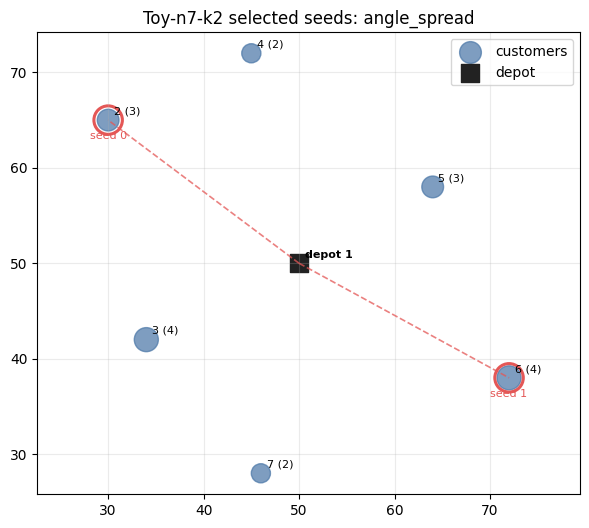

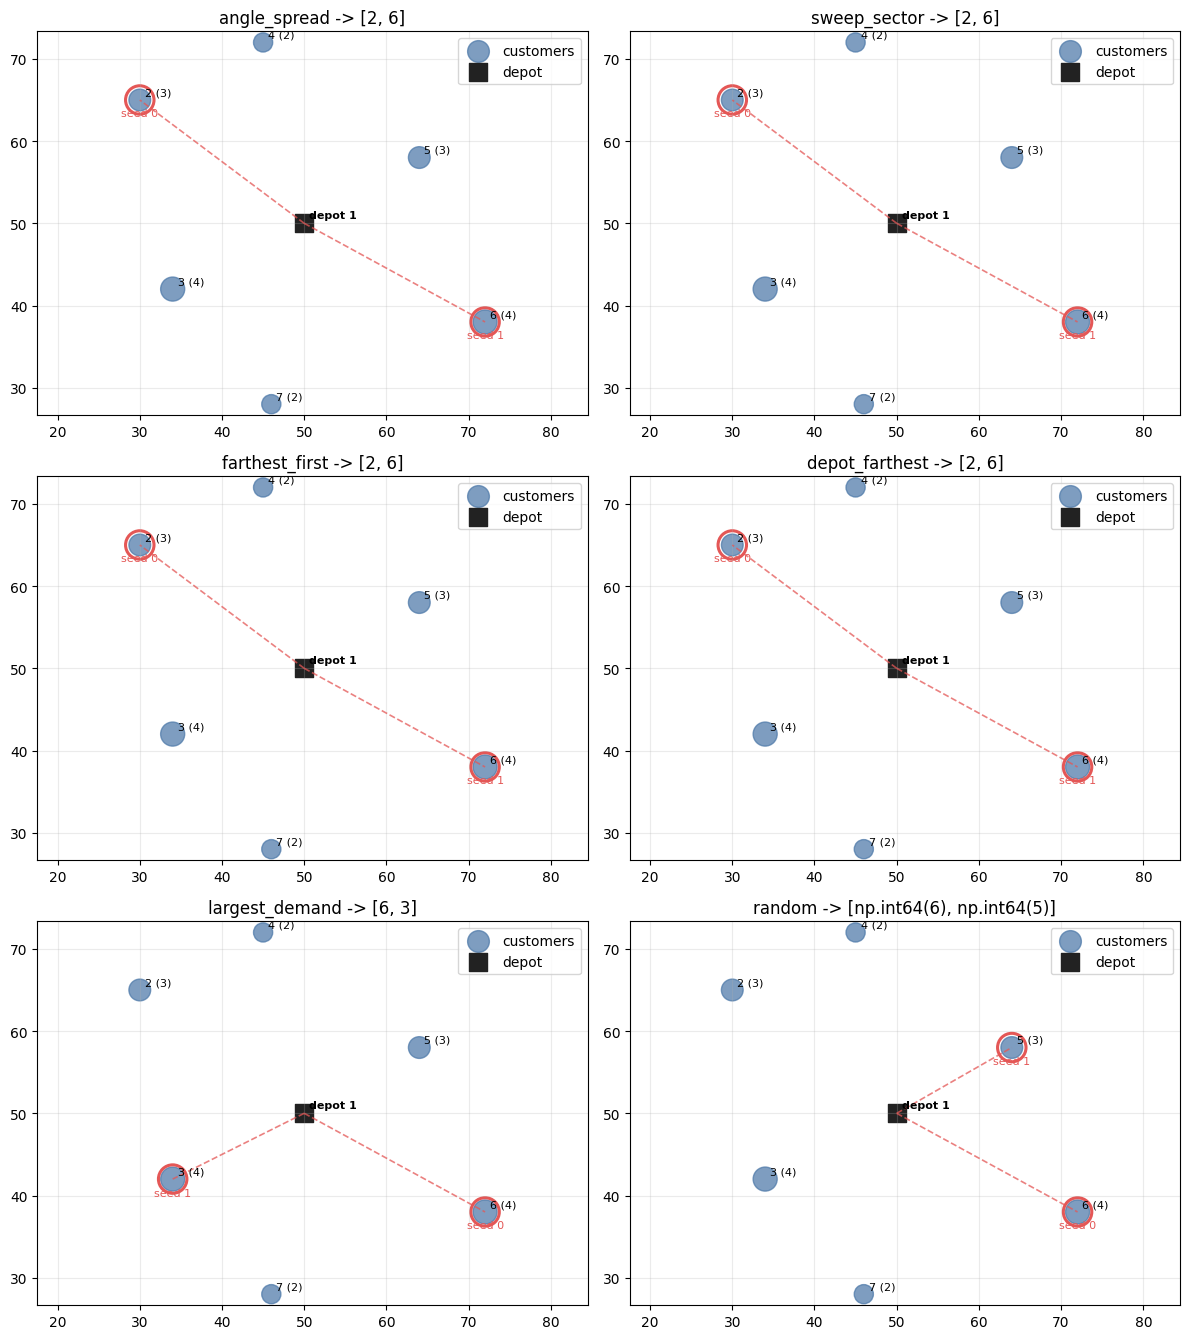

In [52]:
def _plot_base_instance(instance, ax, title):
    if not instance.get('coords'):
        ax.set_axis_off()
        ax.set_title(title)
        ax.text(0.5, 0.5, 'No coordinates available', ha='center', va='center', transform=ax.transAxes)
        return

    depot = instance['depot']
    customers = instance['customers']
    max_demand = max(instance['demands'][customer] for customer in customers)

    customer_x = [instance['coords'][customer][0] for customer in customers]
    customer_y = [instance['coords'][customer][1] for customer in customers]
    customer_sizes = [80 + 220 * instance['demands'][customer] / max_demand for customer in customers]

    ax.scatter(customer_x, customer_y, s=customer_sizes, c='#4C78A8', alpha=0.72, label='customers')
    ax.scatter(
        [instance['coords'][depot][0]],
        [instance['coords'][depot][1]],
        marker='s',
        s=180,
        c='#222222',
        label='depot',
    )

    for customer in customers:
        x_coord, y_coord = instance['coords'][customer]
        ax.text(x_coord + 0.6, y_coord + 0.6, f"{customer} ({instance['demands'][customer]})", fontsize=8)

    depot_x, depot_y = instance['coords'][depot]
    ax.text(depot_x + 0.6, depot_y + 0.6, f"depot {depot}", fontsize=8, fontweight='bold')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='datalim')
    ax.grid(True, alpha=0.25)


def plot_instance_and_seeds(instance, seeds, title=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    title = title or f"{instance['metadata'].get('NAME', instance['path'].stem)} seeds"
    _plot_base_instance(instance, ax, title)
    if not instance.get('coords'):
        return ax

    depot_x, depot_y = instance['coords'][instance['depot']]
    for seed_index, seed in enumerate(seeds):
        seed_x, seed_y = instance['coords'][seed]
        ax.scatter([seed_x], [seed_y], s=420, facecolors='none', edgecolors='#E45756', linewidths=2.2)
        ax.plot([depot_x, seed_x], [depot_y, seed_y], color='#E45756', linestyle='--', linewidth=1.2, alpha=0.75)
        ax.text(seed_x, seed_y - 2.0, f"seed {seed_index}", color='#E45756', fontsize=8, ha='center')
    ax.legend(loc='best')
    return ax


def plot_seed_method_grid(instance, seed_rows):
    if not instance.get('coords'):
        print('Skipping seed-method grid: this instance has no coordinates.')
        return None

    available_rows = [row for row in seed_rows if row.get('seeds')]
    columns = 2
    rows = math.ceil(len(available_rows) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(12, 4.5 * rows), squeeze=False)
    for ax, row in zip(axes.ravel(), available_rows):
        plot_instance_and_seeds(instance, row['seeds'], title=f"{row['method']} -> {row['seeds']}", ax=ax)
    for ax in axes.ravel()[len(available_rows):]:
        ax.set_axis_off()
    fig.tight_layout()
    return fig


plot_instance_and_seeds(
    instance,
    seeds,
    title=f"{instance['metadata'].get('NAME', instance['path'].stem)} selected seeds: {seed_method_used}",
)
plot_seed_method_grid(instance, seed_comparison_rows)
plt.show()


## GAP clustering QUBO

The clustering variables are `z_customer_vehicle`:

- `z_i_k = 1` means customer `i` is assigned to vehicle `k`
- each customer is assigned exactly once
- each vehicle load is constrained by capacity in the hard-capacity baseline
- each seed is fixed to its own vehicle
- the objective minimizes Fisher-Jaikumar seed insertion costs

The hard-capacity baseline below uses Qiskit's inequality conversion, so capacity introduces slack bits. The Taylor and tilted penalty variants in the next section remove those capacity constraints and put their penalties directly in the objective.


In [53]:
def assignment_variable_name(customer, vehicle):
    return f'z_{customer}_{vehicle}'


def fisher_jaikumar_assignment_cost(instance, customer, seed):
    depot = instance['depot']
    return (
        euclidean_distance(instance, depot, customer)
        + euclidean_distance(instance, customer, seed)
        - euclidean_distance(instance, depot, seed)
    )


def build_fisher_jaikumar_gap_qp(instance, seeds):
    customers = instance['customers']
    num_vehicles = len(seeds)
    capacity = int(instance['metadata']['CAPACITY'])
    qp = QuadraticProgram('cvrp_fisher_jaikumar_gap')

    for customer in customers:
        for vehicle in range(num_vehicles):
            qp.binary_var(name=assignment_variable_name(customer, vehicle))

    linear_objective = {}
    for customer in customers:
        for vehicle, seed in enumerate(seeds):
            linear_objective[assignment_variable_name(customer, vehicle)] = fisher_jaikumar_assignment_cost(
                instance,
                customer,
                seed,
            )
    qp.minimize(linear=linear_objective)

    for customer in customers:
        qp.linear_constraint(
            linear={assignment_variable_name(customer, vehicle): 1 for vehicle in range(num_vehicles)},
            sense='==',
            rhs=1,
            name=f'assign_customer_{customer}',
        )

    for vehicle in range(num_vehicles):
        qp.linear_constraint(
            linear={
                assignment_variable_name(customer, vehicle): instance['demands'][customer]
                for customer in customers
            },
            sense='<=',
            rhs=capacity,
            name=f'capacity_vehicle_{vehicle}',
        )

    for vehicle, seed in enumerate(seeds):
        qp.linear_constraint(
            linear={assignment_variable_name(seed, vehicle): 1},
            sense='==',
            rhs=1,
            name=f'fix_seed_{seed}_vehicle_{vehicle}',
        )

    return qp


gap_qp = build_fisher_jaikumar_gap_qp(instance, seeds)
gap_converter = QuadraticProgramToQubo()
gap_qubo = gap_converter.convert(gap_qp)

print('Fisher-Jaikumar GAP')
print(f"Original GAP variables: {gap_qp.get_num_vars()}")
print(f"Original GAP constraints: {len(gap_qp.linear_constraints)}")
print(f"GAP QUBO variables / direct qubits: {gap_qubo.get_num_vars()}")
print(f"Converter penalty: {gap_converter.penalty}")


Fisher-Jaikumar GAP
Original GAP variables: 12
Original GAP constraints: 10
GAP QUBO variables / direct qubits: 20
Converter penalty: 305.0


In [54]:
GAP_LP_PREVIEW_CHARS = 4000

gap_qubo_lp = gap_qubo.export_as_lp_string()
print(gap_qubo_lp[:GAP_LP_PREVIEW_CHARS])
if len(gap_qubo_lp) > GAP_LP_PREVIEW_CHARS:
    print()
    print(f"... truncated {len(gap_qubo_lp) - GAP_LP_PREVIEW_CHARS} characters")


/var/folders/tm/6bh1bn3x6pgfgp8nvpknylq40000gn/T/ipykernel_42094/652628129.py:3: DeprecationWarning: The method ``qiskit_optimization.problems.quadratic_program.QuadraticProgram.export_as_lp_string()`` is deprecated as of Qiskit 0.7.0. It will be removed no earlier than 3 months after the release date. Use prettyprint instead.
  gap_qubo_lp = gap_qubo.export_as_lp_string()


\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: cvrp_fisher_jaikumar_gap

Minimize
 obj: - 17690 z_2_0 - 17030 z_2_1 - 22554 z_3_0 - 22539 z_3_1 - 11575 z_4_0
      - 11549 z_4_1 - 17054 z_5_0 - 17067 z_5_1 - 22520 z_6_0 - 23180 z_6_1
      - 11553 z_7_0 - 11565 z_7_1 - 5490 capacity_vehicle_0@int_slack@0
      - 10980 capacity_vehicle_0@int_slack@1
      - 21960 capacity_vehicle_0@int_slack@2
      - 10980 capacity_vehicle_0@int_slack@3
      - 5490 capacity_vehicle_1@int_slack@0
      - 10980 capacity_vehicle_1@int_slack@1
      - 21960 capacity_vehicle_1@int_slack@2
      - 10980 capacity_vehicle_1@int_slack@3 + [ 6710 z_2_0^2 + 1220 z_2_0*z_2_1
      + 14640 z_2_0*z_3_0 + 7320 z_2_0*z_4_0 + 10980 z_2_0*z_5_0
      + 14640 z_2_0*z_6_0 + 7320 z_2_0*z_7_0
      + 3660 z_2_0*capacity_vehicle_0@int_slack@0
      + 7320 z_2_0*capacity_vehicle_0@int_slack@1
      + 14640 z_2_0*capacity_vehicle_0@int_slack@2
      + 7320 z_2_0*capacity_vehicle_0@int_slack@3 +

## No-slack capacity penalty variants

The two cells below adapt the Taylor and tilted quadratic penalties from the knapsack files to each vehicle-load expression in the Fisher-Jaikumar GAP.

For each vehicle `k`, let `W_k = sum_i demand_i * z_i_k`.

- Taylor penalty: `alpha * (1 - t + 0.5 * t^2)`, where `t = capacity - W_k`.
- Tilted quadratic penalty: `rho * ((W_k - capacity)^2 + s * (W_k - capacity))`.

These versions do not add capacity inequalities to the `QuadraticProgram`, so `QuadraticProgramToQubo` does not introduce capacity slack variables. Assignment and seed-fixing constraints remain hard equality penalties in the converter and do not add variables.


In [55]:
def _add_quadratic_terms(target, terms):
    for key, value in terms.items():
        target[key] = target.get(key, 0.0) + float(value)


def _gap_base_objective(instance, seeds):
    linear = {}
    for customer in instance['customers']:
        for vehicle, seed in enumerate(seeds):
            variable = assignment_variable_name(customer, vehicle)
            linear[variable] = fisher_jaikumar_assignment_cost(instance, customer, seed)
    return 0.0, linear, {}


def _add_assignment_and_seed_constraints(qp, instance, seeds):
    num_vehicles = len(seeds)
    for customer in instance['customers']:
        qp.linear_constraint(
            linear={assignment_variable_name(customer, vehicle): 1 for vehicle in range(num_vehicles)},
            sense='==',
            rhs=1,
            name=f'assign_customer_{customer}',
        )

    for vehicle, seed in enumerate(seeds):
        qp.linear_constraint(
            linear={assignment_variable_name(seed, vehicle): 1},
            sense='==',
            rhs=1,
            name=f'fix_seed_{seed}_vehicle_{vehicle}',
        )


def _add_taylor_capacity_penalty(linear, quadratic, instance, vehicle, alpha):
    capacity = int(instance['metadata']['CAPACITY'])
    constant = alpha * (1.0 - capacity + 0.5 * capacity * capacity)

    for customer in instance['customers']:
        variable = assignment_variable_name(customer, vehicle)
        demand = float(instance['demands'][customer])
        linear[variable] = linear.get(variable, 0.0) + alpha * ((1.0 - capacity) * demand + 0.5 * demand * demand)

    for left_index, left in enumerate(instance['customers']):
        for right in instance['customers'][left_index + 1:]:
            left_var = assignment_variable_name(left, vehicle)
            right_var = assignment_variable_name(right, vehicle)
            value = alpha * float(instance['demands'][left]) * float(instance['demands'][right])
            quadratic[(left_var, right_var)] = quadratic.get((left_var, right_var), 0.0) + value

    return constant


def _tilted_s(capacity, s_frac=0.10, s_min=1):
    if capacity <= 0:
        raise ValueError('capacity must be positive')
    return float(max(s_min, int(s_frac * capacity)))


def _tilted_rho(instance, seeds, kappa=5.0, eps=1e-12):
    min_demand = min(float(instance['demands'][customer]) for customer in instance['customers'])
    if min_demand <= 0:
        raise ValueError('Customer demands must be positive for rho scaling')

    cost_scale = max(
        abs(float(fisher_jaikumar_assignment_cost(instance, customer, seed)))
        for customer in instance['customers']
        for seed in seeds
    )
    cost_scale = max(cost_scale, 1.0)
    return float((kappa * cost_scale) / (min_demand * min_demand + eps))


def _add_tilted_capacity_penalty(linear, quadratic, instance, vehicle, rho, s):
    capacity = int(instance['metadata']['CAPACITY'])
    constant = rho * (capacity * capacity - s * capacity)
    linear_factor = rho * (s - 2.0 * capacity)

    for customer in instance['customers']:
        variable = assignment_variable_name(customer, vehicle)
        demand = float(instance['demands'][customer])
        linear[variable] = linear.get(variable, 0.0) + linear_factor * demand + rho * demand * demand

    for left_index, left in enumerate(instance['customers']):
        for right in instance['customers'][left_index + 1:]:
            left_var = assignment_variable_name(left, vehicle)
            right_var = assignment_variable_name(right, vehicle)
            value = 2.0 * rho * float(instance['demands'][left]) * float(instance['demands'][right])
            quadratic[(left_var, right_var)] = quadratic.get((left_var, right_var), 0.0) + value

    return constant


def build_fisher_jaikumar_gap_taylor_penalty_qp(instance, seeds, alpha=10.0):
    qp = QuadraticProgram('cvrp_fisher_jaikumar_gap_taylor_penalty')
    for customer in instance['customers']:
        for vehicle in range(len(seeds)):
            qp.binary_var(name=assignment_variable_name(customer, vehicle))

    constant, linear, quadratic = _gap_base_objective(instance, seeds)
    for vehicle in range(len(seeds)):
        constant += _add_taylor_capacity_penalty(linear, quadratic, instance, vehicle, alpha=alpha)

    qp.minimize(constant=constant, linear=linear, quadratic=quadratic)
    _add_assignment_and_seed_constraints(qp, instance, seeds)
    return qp


def build_fisher_jaikumar_gap_tilted_penalty_qp(
    instance,
    seeds,
    kappa=5.0,
    s_frac=0.10,
    s_min=1,
    rho=None,
    s=None,
):
    qp = QuadraticProgram('cvrp_fisher_jaikumar_gap_tilted_penalty')
    for customer in instance['customers']:
        for vehicle in range(len(seeds)):
            qp.binary_var(name=assignment_variable_name(customer, vehicle))

    capacity = int(instance['metadata']['CAPACITY'])
    s_used = float(s) if s is not None else _tilted_s(capacity, s_frac=s_frac, s_min=s_min)
    rho_used = float(rho) if rho is not None else _tilted_rho(instance, seeds, kappa=kappa)

    constant, linear, quadratic = _gap_base_objective(instance, seeds)
    for vehicle in range(len(seeds)):
        constant += _add_tilted_capacity_penalty(
            linear,
            quadratic,
            instance,
            vehicle,
            rho=rho_used,
            s=s_used,
        )

    qp.minimize(constant=constant, linear=linear, quadratic=quadratic)
    _add_assignment_and_seed_constraints(qp, instance, seeds)
    return qp, rho_used, s_used


In [56]:
TAYLOR_ALPHA = 10.0
TILTED_KAPPA = 5.0
TILTED_S_FRAC = 0.10
TILTED_S_MIN = 1

taylor_gap_qp = build_fisher_jaikumar_gap_taylor_penalty_qp(
    instance,
    seeds,
    alpha=TAYLOR_ALPHA,
)
taylor_gap_converter = QuadraticProgramToQubo()
taylor_gap_qubo = taylor_gap_converter.convert(taylor_gap_qp)

tilted_gap_qp, tilted_rho_used, tilted_s_used = build_fisher_jaikumar_gap_tilted_penalty_qp(
    instance,
    seeds,
    kappa=TILTED_KAPPA,
    s_frac=TILTED_S_FRAC,
    s_min=TILTED_S_MIN,
)
tilted_gap_converter = QuadraticProgramToQubo()
tilted_gap_qubo = tilted_gap_converter.convert(tilted_gap_qp)

print('| GAP formulation | original variables | constraints | QUBO variables / direct qubits | converter penalty | penalty parameters |')
print('| --- | --- | --- | --- | --- | --- |')
print(f"| Hard capacity with converter slack | {gap_qp.get_num_vars()} | {len(gap_qp.linear_constraints)} | {gap_qubo.get_num_vars()} | {gap_converter.penalty} | capacity inequalities |")
print(f"| Taylor no-slack capacity penalty | {taylor_gap_qp.get_num_vars()} | {len(taylor_gap_qp.linear_constraints)} | {taylor_gap_qubo.get_num_vars()} | {taylor_gap_converter.penalty} | alpha={TAYLOR_ALPHA} |")
print(f"| Tilted no-slack capacity penalty | {tilted_gap_qp.get_num_vars()} | {len(tilted_gap_qp.linear_constraints)} | {tilted_gap_qubo.get_num_vars()} | {tilted_gap_converter.penalty} | rho={tilted_rho_used:.6g}, s={tilted_s_used:.6g} |")


| GAP formulation | original variables | constraints | QUBO variables / direct qubits | converter penalty | penalty parameters |
| --- | --- | --- | --- | --- | --- |
| Hard capacity with converter slack | 12 | 10 | 20 | 305.0 | capacity inequalities |
| Taylor no-slack capacity penalty | 12 | 8 | 12 | 4657.0 | alpha=10.0 |
| Tilted no-slack capacity penalty | 12 | 8 | 12 | 63946.999999983935 | rho=62.5, s=1 |


## Penalty QUBO previews

The following cell prints small LP previews for the Taylor and tilted penalty GAP QUBOs. These are classical QUBO exports only; no quantum simulation or optimization is run.


In [57]:
PENALTY_LP_PREVIEW_CHARS = 3000

print('Taylor no-slack GAP QUBO preview')
taylor_lp = taylor_gap_qubo.export_as_lp_string()
print(taylor_lp[:PENALTY_LP_PREVIEW_CHARS])
if len(taylor_lp) > PENALTY_LP_PREVIEW_CHARS:
    print()
    print(f"... truncated {len(taylor_lp) - PENALTY_LP_PREVIEW_CHARS} characters")

print()
print('Tilted no-slack GAP QUBO preview')
tilted_lp = tilted_gap_qubo.export_as_lp_string()
print(tilted_lp[:PENALTY_LP_PREVIEW_CHARS])
if len(tilted_lp) > PENALTY_LP_PREVIEW_CHARS:
    print()
    print(f"... truncated {len(tilted_lp) - PENALTY_LP_PREVIEW_CHARS} characters")


Taylor no-slack GAP QUBO preview


/var/folders/tm/6bh1bn3x6pgfgp8nvpknylq40000gn/T/ipykernel_42094/95765420.py:4: DeprecationWarning: The method ``qiskit_optimization.problems.quadratic_program.QuadraticProgram.export_as_lp_string()`` is deprecated as of Qiskit 0.7.0. It will be removed no earlier than 3 months after the release date. Use prettyprint instead.
  taylor_lp = taylor_gap_qubo.export_as_lp_string()


\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: cvrp_fisher_jaikumar_gap_taylor_penalty

Minimize
 obj: - 18823 z_2_0 - 9459 z_2_1 - 9538 z_3_0 - 9523 z_3_1 - 9439 z_4_0
      - 9413 z_4_1 - 9483 z_5_0 - 9496 z_5_1 - 9504 z_6_0 - 18868 z_6_1
      - 9417 z_7_0 - 9429 z_7_1 + [ 18628 z_2_0^2 + 18628 z_2_0*z_2_1
      + 240 z_2_0*z_3_0 + 120 z_2_0*z_4_0 + 180 z_2_0*z_5_0 + 240 z_2_0*z_6_0
      + 120 z_2_0*z_7_0 + 9314 z_2_1^2 + 240 z_2_1*z_3_1 + 120 z_2_1*z_4_1
      + 180 z_2_1*z_5_1 + 240 z_2_1*z_6_1 + 120 z_2_1*z_7_1 + 9314 z_3_0^2
      + 18628 z_3_0*z_3_1 + 160 z_3_0*z_4_0 + 240 z_3_0*z_5_0 + 320 z_3_0*z_6_0
      + 160 z_3_0*z_7_0 + 9314 z_3_1^2 + 160 z_3_1*z_4_1 + 240 z_3_1*z_5_1
      + 320 z_3_1*z_6_1 + 160 z_3_1*z_7_1 + 9314 z_4_0^2 + 18628 z_4_0*z_4_1
      + 120 z_4_0*z_5_0 + 160 z_4_0*z_6_0 + 80 z_4_0*z_7_0 + 9314 z_4_1^2
      + 120 z_4_1*z_5_1 + 160 z_4_1*z_6_1 + 80 z_4_1*z_7_1 + 9314 z_5_0^2
      + 18628 z_5_0*z_5_1 + 240 z_5_0*z_6_0 + 120

/var/folders/tm/6bh1bn3x6pgfgp8nvpknylq40000gn/T/ipykernel_42094/95765420.py:12: DeprecationWarning: The method ``qiskit_optimization.problems.quadratic_program.QuadraticProgram.export_as_lp_string()`` is deprecated as of Qiskit 0.7.0. It will be removed no earlier than 3 months after the release date. Use prettyprint instead.
  tilted_lp = tilted_gap_qubo.export_as_lp_string()


\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: cvrp_fisher_jaikumar_gap_tilted_penalty

Minimize
 obj: - 258412.999999935098 z_2_0 - 130468.999999967215 z_2_1
      - 131127.999999967054 z_3_0 - 131112.999999967054 z_3_1
      - 129753.999999967404 z_4_0 - 129727.999999967404 z_4_1
      - 130492.999999967215 z_5_0 - 130505.999999967215 z_5_1
      - 131093.999999967054 z_6_0 - 259037.999999934924 z_6_1
      - 129731.999999967404 z_7_0 - 129743.999999967404 z_7_1 + [
      255787.999999935739 z_2_0^2 + 255787.999999935739 z_2_0*z_2_1
      + 2999.999999999250 z_2_0*z_3_0 + 1499.999999999625 z_2_0*z_4_0
      + 2249.999999999437 z_2_0*z_5_0 + 2999.999999999250 z_2_0*z_6_0
      + 1499.999999999625 z_2_0*z_7_0 + 127893.999999967869 z_2_1^2
      + 2999.999999999250 z_2_1*z_3_1 + 1499.999999999625 z_2_1*z_4_1
      + 2249.999999999437 z_2_1*z_5_1 + 2999.999999999250 z_2_1*z_6_1
      + 1499.999999999625 z_2_1*z_7_1 + 127893.999999967869 z_3_0^2
      + 255

## Decode GAP output into clusters

The GAP VQE step returns sampled bitstrings in the selected GAP QUBO variable space. To build the route-second TSP QUBOs, first map a QUBO vector back to the original GAP variable vector with the matching converter, for example `gap_converter.interpret(qubo_vector)`, `taylor_gap_converter.interpret(qubo_vector)`, or `tilted_gap_converter.interpret(qubo_vector)`. Then decode the `z_customer_vehicle` values into clusters.

The functions below are used by the VQE post-processing step to turn the selected GAP sample into route clusters.


In [58]:
def decode_gap_original_assignment(original_gap_vector, gap_qp, customers, num_vehicles):
    values_by_name = {
        variable.name: int(round(original_gap_vector[index]))
        for index, variable in enumerate(gap_qp.variables)
    }
    clusters = [[] for _ in range(num_vehicles)]
    for customer in customers:
        assigned = [
            vehicle
            for vehicle in range(num_vehicles)
            if values_by_name.get(assignment_variable_name(customer, vehicle), 0) == 1
        ]
        if len(assigned) != 1:
            raise ValueError(f'Customer {customer} assigned to {assigned}; expected exactly one vehicle.')
        clusters[assigned[0]].append(customer)
    return clusters


def route_stage_qubit_counts(clusters):
    per_route = [len(cluster) ** 2 for cluster in clusters]
    return {
        'per_route': per_route,
        'sequential_qubits': max(per_route) if per_route else 0,
        'combined_qubits': sum(per_route),
    }


## Select the GAP QUBO for VQE

The notebook builds three GAP QUBOs above. `GAP_QUBO_METHOD` chooses which one goes into VQE:

- `hard`: exact capacity inequalities converted with slack variables; more qubits.
- `taylor`: Taylor no-slack capacity penalty; fewer qubits.
- `tilted`: tilted no-slack capacity penalty; fewer qubits and the default here.

The no-slack methods still keep assignment and seed-fixing constraints as hard equality penalties through `QuadraticProgramToQubo`. Capacity is handled by the selected penalty shape, and the decoder checks final cluster loads before routing.


In [59]:
def select_gap_qubo_model(method):
    models = {
        'hard': {
            'method': 'hard',
            'description': 'hard capacity with converter slack',
            'qp': gap_qp,
            'qubo': gap_qubo,
            'converter': gap_converter,
        },
        'taylor': {
            'method': 'taylor',
            'description': 'Taylor no-slack capacity penalty',
            'qp': taylor_gap_qp,
            'qubo': taylor_gap_qubo,
            'converter': taylor_gap_converter,
        },
        'tilted': {
            'method': 'tilted',
            'description': 'tilted no-slack capacity penalty',
            'qp': tilted_gap_qp,
            'qubo': tilted_gap_qubo,
            'converter': tilted_gap_converter,
        },
    }
    if method not in models:
        raise ValueError(f"Unknown GAP_QUBO_METHOD {method!r}. Choose from {sorted(models)}")
    return models[method]


GAP_QUBO_METHOD = 'tilted'
selected_gap_model = select_gap_qubo_model(GAP_QUBO_METHOD)

print(f"Selected GAP QUBO method: {selected_gap_model['description']}")
print(f"Original variables: {selected_gap_model['qp'].get_num_vars()}")
print(f"Original constraints: {len(selected_gap_model['qp'].linear_constraints)}")
print(f"QUBO variables / VQE qubits: {selected_gap_model['qubo'].get_num_vars()}")


Selected GAP QUBO method: tilted no-slack capacity penalty
Original variables: 12
Original constraints: 8
QUBO variables / VQE qubits: 12


## VQE utilities

This follows the same VQE style as `maxcut_vqe_simulator.ipynb`:

- build an `efficient_su2` ansatz
- evaluate the Ising Hamiltonian with `BackendEstimatorV2`
- optimize the parameters using SciPy `minimize(..., method='cobyla')`
- assign the optimized parameters, measure the circuit, and sample with `BackendSamplerV2`
- decode the most useful sampled bitstrings back into `QuadraticProgram` variable order

The sampler integer bitstrings are reversed before interpretation, matching the MaxCut notebook's post-processing pattern.


In [60]:
def integer_to_variable_vector(integer, num_bits):
    bitstring = np.binary_repr(integer, width=num_bits)
    bits = [int(digit) for digit in bitstring]
    bits.reverse()
    return np.array(bits, dtype=int)


def integer_to_display_bitstring(integer, num_bits):
    return np.binary_repr(integer, width=num_bits)


def cost_func(params, ansatz, hamiltonian, estimator, cost_history_dict, verbose=False):
    pub = (ansatz, [hamiltonian], [params])
    result = estimator.run(pubs=[pub]).result()
    energy = float(np.real(result[0].data.evs[0]))

    cost_history_dict['iters'] += 1
    cost_history_dict['prev_vector'] = params
    cost_history_dict['cost_history'].append(energy)
    if verbose:
        print(f"Iters. done: {cost_history_dict['iters']} [Current cost: {energy}]")
    return energy


def run_vqe_for_qubo(qubo, label, reps=1, maxiter=200, seed=7, shots=4096, verbose=False):
    qubit_op, offset = qubo.to_ising()
    ansatz = efficient_su2(qubit_op.num_qubits, reps=reps).decompose()
    num_params = ansatz.num_parameters
    rng = np.random.default_rng(seed)
    x0 = 2.0 * np.pi * rng.random(num_params)
    cost_history_dict = {
        'prev_vector': None,
        'iters': 0,
        'cost_history': [],
    }

    optimizer_result = minimize(
        cost_func,
        x0,
        args=(ansatz, qubit_op, estimator, cost_history_dict, verbose),
        method='cobyla',
        options={'maxiter': maxiter},
    )

    optimized_ansatz = ansatz.assign_parameters(optimizer_result.x)
    measured_ansatz = optimized_ansatz.copy()
    measured_ansatz.measure_all()

    pub = (measured_ansatz,)
    job = sampler.run([pub], shots=shots)
    sample_result = job.result()[0].data.meas
    counts_int = sample_result.get_int_counts()
    counts_bin = sample_result.get_counts()
    total_shots = sum(counts_int.values())
    final_distribution_int = {key: value / total_shots for key, value in counts_int.items()}
    final_distribution_bin = {key: value / total_shots for key, value in counts_bin.items()}

    return {
        'label': label,
        'qubit_op': qubit_op,
        'offset': offset,
        'ansatz': ansatz,
        'optimized_ansatz': optimized_ansatz,
        'measured_ansatz': measured_ansatz,
        'optimizer_result': optimizer_result,
        'cost_history': cost_history_dict,
        'counts_int': counts_int,
        'counts_bin': counts_bin,
        'final_distribution_int': final_distribution_int,
        'final_distribution_bin': final_distribution_bin,
        'num_qubits': qubit_op.num_qubits,
        'shots': total_shots,
        'estimated_qubo_objective': float(optimizer_result.fun + offset),
    }


def rank_vqe_sampled_candidates(
    distribution_int,
    num_bits,
    qubo,
    converter,
    original_qp,
    feasibility_checker=None,
):
    rows = []
    for integer, probability in sorted(distribution_int.items(), key=lambda item: item[1], reverse=True):
        qubo_x = integer_to_variable_vector(integer, num_bits)
        original_x = np.array(converter.interpret(qubo_x), dtype=int)
        base_feasible = original_qp.is_feasible(original_x)
        custom_feasible = True if feasibility_checker is None else feasibility_checker(original_x)
        rows.append(
            {
                'integer': int(integer),
                'bitstring': integer_to_display_bitstring(integer, num_bits),
                'probability': float(probability),
                'qubo_x': qubo_x,
                'original_x': original_x,
                'qubo_objective': float(qubo.objective.evaluate(qubo_x)),
                'original_objective': float(original_qp.objective.evaluate(original_x)),
                'feasible': bool(base_feasible and custom_feasible),
                'base_feasible': bool(base_feasible),
                'custom_feasible': bool(custom_feasible),
            }
        )

    feasible_rows = [row for row in rows if row['feasible']]
    if feasible_rows:
        selected = min(feasible_rows, key=lambda row: (row['qubo_objective'], -row['probability']))
        selected['selection_note'] = 'lowest QUBO objective among feasible sampled VQE bitstrings'
    else:
        selected = min(rows, key=lambda row: (row['qubo_objective'], -row['probability']))
        selected['selection_note'] = 'no feasible sampled bitstring; selected lowest QUBO objective sampled candidate'

    return selected, rows


def print_vqe_candidate_table(rows, limit=10):
    print('| rank | bitstring | probability | QUBO objective | original objective | feasible |')
    print('| --- | --- | --- | --- | --- | --- |')
    for rank, row in enumerate(rows[:limit], start=1):
        print(
            f"| {rank} | {row['bitstring']} | {row['probability']:.6f} | "
            f"{row['qubo_objective']:.6f} | {row['original_objective']:.6f} | {row['feasible']} |"
        )


## Run VQE on the GAP QUBO and decode clusters

This cell solves the selected GAP QUBO with local VQE, post-processes the most likely VQE bitstrings, and decodes the selected bitstring into Fisher-Jaikumar clusters.

For no-slack capacity penalties, capacity is not a hard converter constraint, so the decoder separately reports whether the selected clusters respect vehicle capacity.


In [61]:
def gap_clusters_from_original_vector(original_gap_vector, gap_qp, instance, num_vehicles):
    return decode_gap_original_assignment(
        original_gap_vector,
        gap_qp,
        instance['customers'],
        num_vehicles,
    )


def gap_capacity_report(instance, clusters):
    capacity = int(instance['metadata']['CAPACITY'])
    route_loads = [sum(instance['demands'][customer] for customer in cluster) for cluster in clusters]
    return {
        'capacity': capacity,
        'loads': route_loads,
        'capacity_feasible': all(load <= capacity for load in route_loads),
    }


def gap_capacity_feasibility_checker(original_gap_vector):
    try:
        candidate_clusters = gap_clusters_from_original_vector(
            original_gap_vector,
            selected_gap_model['qp'],
            instance,
            parsed_vehicle_count,
        )
    except ValueError:
        return False
    return gap_capacity_report(instance, candidate_clusters)['capacity_feasible']


GAP_VQE_REPS = 1
GAP_VQE_MAXITER = 220
GAP_VQE_SEED = 11
GAP_VQE_SHOTS = 4096

vqe_gap_result = run_vqe_for_qubo(
    selected_gap_model['qubo'],
    label=f"GAP-{selected_gap_model['method']}",
    reps=GAP_VQE_REPS,
    maxiter=GAP_VQE_MAXITER,
    seed=GAP_VQE_SEED,
    shots=GAP_VQE_SHOTS,
    verbose=False,
)

vqe_gap_selected, vqe_gap_candidates = rank_vqe_sampled_candidates(
    vqe_gap_result['final_distribution_int'],
    vqe_gap_result['num_qubits'],
    selected_gap_model['qubo'],
    selected_gap_model['converter'],
    selected_gap_model['qp'],
    feasibility_checker=gap_capacity_feasibility_checker,
)
if not vqe_gap_selected['feasible']:
    raise ValueError('GAP VQE did not sample a feasible decoded CVRP cluster assignment. Increase GAP_VQE_SHOTS / GAP_VQE_MAXITER or change GAP_QUBO_METHOD.')


vqe_gap_clusters = gap_clusters_from_original_vector(
    vqe_gap_selected['original_x'],
    selected_gap_model['qp'],
    instance,
    parsed_vehicle_count,
)
vqe_gap_capacity = gap_capacity_report(instance, vqe_gap_clusters)

print(f"GAP VQE method: {selected_gap_model['description']}")
print(f"GAP VQE qubits: {vqe_gap_result['num_qubits']}")
print(f"VQE estimated QUBO objective: {vqe_gap_result['estimated_qubo_objective']:.6f}")
print(f"VQE iterations: {vqe_gap_result['cost_history']['iters']}")
print(f"VQE shots: {vqe_gap_result['shots']}")
print(f"Selected bitstring: {vqe_gap_selected['bitstring']}")
print(f"Selected bitstring probability: {vqe_gap_selected['probability']:.6f}")
print(f"Selected QUBO objective: {vqe_gap_selected['qubo_objective']:.6f}")
print(f"Selection note: {vqe_gap_selected['selection_note']}")
print(f"Decoded clusters: {vqe_gap_clusters}")
print(f"Cluster loads: {vqe_gap_capacity['loads']} / capacity {vqe_gap_capacity['capacity']}")
print(f"Capacity feasible: {vqe_gap_capacity['capacity_feasible']}")
print()
print_vqe_candidate_table(vqe_gap_candidates, limit=10)


GAP VQE method: tilted no-slack capacity penalty
GAP VQE qubits: 12
VQE estimated QUBO objective: 13858.936035
VQE iterations: 220
VQE shots: 4096
Selected bitstring: 101010010101
Selected bitstring probability: 0.011230
Selected QUBO objective: 69.000000
Selection note: lowest QUBO objective among feasible sampled VQE bitstrings
Decoded clusters: [[2, 3, 4], [5, 6, 7]]
Cluster loads: [9, 9] / capacity 9
Capacity feasible: True

| rank | bitstring | probability | QUBO objective | original objective | feasible |
| --- | --- | --- | --- | --- | --- |
| 1 | 011001100101 | 0.139893 | 1245.000000 | 1245.000000 | False |
| 2 | 011010011001 | 0.116699 | 596.000000 | 596.000000 | False |
| 3 | 011010100101 | 0.095459 | 107.000000 | 107.000000 | True |
| 4 | 011001011001 | 0.092041 | 234.000000 | 234.000000 | False |
| 5 | 011001101001 | 0.060791 | 260.000000 | 260.000000 | False |
| 6 | 101001100101 | 0.046631 | 233.000000 | 233.000000 | False |
| 7 | 011010101001 | 0.044678 | 2122.000000 | 21

## Route-second TSP QUBO builder

Once GAP clusters are available, each cluster becomes one TSP assignment QUBO:

- `y_customer_position = 1` means a customer is placed at a route position
- every customer appears exactly once
- every position gets exactly one customer
- the depot is fixed before the first customer and after the last customer

A cluster with `r` customers produces `r * r` QUBO variables. The route stage can be solved exactly classically, which is useful for checking the full CVRP route cost, or with the same VQE helper used for the GAP stage.


In [62]:
def build_route_second_tsp_qp(instance, cluster, name):
    depot = instance['depot']
    n = len(cluster)
    if n == 0:
        raise ValueError('Cannot build a TSP QP for an empty cluster.')

    qp = QuadraticProgram(name=name)
    for customer in cluster:
        for position in range(n):
            qp.binary_var(name=f'y_{customer}_{position}')

    linear = {}
    quadratic = {}

    for customer in cluster:
        linear[f'y_{customer}_0'] = linear.get(f'y_{customer}_0', 0.0) + euclidean_distance(instance, depot, customer)
        linear[f'y_{customer}_{n - 1}'] = linear.get(f'y_{customer}_{n - 1}', 0.0) + euclidean_distance(instance, customer, depot)

    for position in range(n - 1):
        for i in cluster:
            for j in cluster:
                if i == j:
                    continue
                key = (f'y_{i}_{position}', f'y_{j}_{position + 1}')
                quadratic[key] = quadratic.get(key, 0.0) + euclidean_distance(instance, i, j)

    qp.minimize(linear=linear, quadratic=quadratic)

    for customer in cluster:
        qp.linear_constraint(
            linear={f'y_{customer}_{position}': 1 for position in range(n)},
            sense='==',
            rhs=1,
            name=f'visit_customer_{customer}',
        )

    for position in range(n):
        qp.linear_constraint(
            linear={f'y_{customer}_{position}': 1 for customer in cluster},
            sense='==',
            rhs=1,
            name=f'one_customer_at_position_{position}',
        )

    return qp


def convert_gap_clusters_to_tsp_qubos(instance, clusters):
    route_models = []
    for route_index, cluster in enumerate(clusters):
        qp = build_route_second_tsp_qp(instance, cluster, name=f'fj_route_{route_index}_tsp')
        converter = QuadraticProgramToQubo()
        qubo = converter.convert(qp)
        route_models.append(
            {
                'route_index': route_index,
                'customers': cluster,
                'load': sum(instance['demands'][customer] for customer in cluster),
                'qp': qp,
                'qubo': qubo,
                'converter': converter,
                'converter_penalty': converter.penalty,
            }
        )
    return route_models


def print_tsp_route_qubo_summary(route_models):
    print('| route | customers | load | TSP QP vars | TSP QP constraints | TSP QUBO vars | penalty |')
    print('| --- | --- | --- | --- | --- | --- | --- |')
    for route in route_models:
        print(
            f"| {route['route_index']} | {route['customers']} | {route['load']} | "
            f"{route['qp'].get_num_vars()} | {len(route['qp'].linear_constraints)} | "
            f"{route['qubo'].get_num_vars()} | {route['converter_penalty']} |"
        )


## Solve route-stage TSPs

`POST_GAP_CLUSTERS` is set to the clusters decoded from the GAP VQE result. `ROUTE_SOLVER` controls how the per-cluster TSPs are solved:

- `classical`: exact enumeration over the tiny route permutations.
- `vqe`: convert each route TSP to QUBO and run VQE, then decode the route assignment bitstring.

For larger instances, keeping the route stage classical is a useful hybrid mode; switching it to `vqe` makes both stages quantum-ready on the toy instance. Because the route VQE is shallow and sampled, its route can be approximate; `classical` is the stable exact check for these tiny TSPs.


In [63]:
def route_cost(instance, route):
    if not route:
        return 0
    depot = instance['depot']
    cost = euclidean_distance(instance, depot, route[0])
    cost += sum(euclidean_distance(instance, left, right) for left, right in zip(route, route[1:]))
    cost += euclidean_distance(instance, route[-1], depot)
    return cost


def solve_route_tsp_classically(instance, cluster):
    best_route = None
    best_cost = math.inf
    for candidate in permutations(cluster):
        candidate_route = list(candidate)
        candidate_cost = route_cost(instance, candidate_route)
        if candidate_cost < best_cost:
            best_route = candidate_route
            best_cost = candidate_cost
    return {'solver': 'classical_exact', 'route': best_route, 'cost': best_cost}


def decode_tsp_original_assignment(original_tsp_vector, tsp_qp, cluster):
    values_by_name = {
        variable.name: int(round(original_tsp_vector[index]))
        for index, variable in enumerate(tsp_qp.variables)
    }
    route = []
    for position in range(len(cluster)):
        assigned = [
            customer
            for customer in cluster
            if values_by_name.get(f'y_{customer}_{position}', 0) == 1
        ]
        if len(assigned) != 1:
            raise ValueError(f'Position {position} assigned to {assigned}; expected exactly one customer.')
        route.append(assigned[0])
    if sorted(route) != sorted(cluster):
        raise ValueError(f'Decoded route {route} does not visit exactly cluster {cluster}.')
    return route


def solve_route_tsp_with_vqe(instance, route_model, reps=1, maxiter=160, seed=17, shots=4096):
    tsp_vqe_result = run_vqe_for_qubo(
        route_model['qubo'],
        label=f"route-{route_model['route_index']}-tsp",
        reps=reps,
        maxiter=maxiter,
        seed=seed + route_model['route_index'],
        shots=shots,
    )
    selected, candidates = rank_vqe_sampled_candidates(
        tsp_vqe_result['final_distribution_int'],
        tsp_vqe_result['num_qubits'],
        route_model['qubo'],
        route_model['converter'],
        route_model['qp'],
    )
    if not selected['feasible']:
        raise ValueError(f"Route {route_model['route_index']} VQE did not sample a feasible TSP assignment. Increase shots/maxiter or use ROUTE_SOLVER='classical'.")
    route = decode_tsp_original_assignment(
        selected['original_x'],
        route_model['qp'],
        route_model['customers'],
    )
    return {
        'solver': 'vqe',
        'route': route,
        'cost': route_cost(instance, route),
        'vqe_result': tsp_vqe_result,
        'selected': selected,
        'candidates': candidates,
    }


def solve_tsp_route_models(instance, route_models, route_solver='classical'):
    route_solutions = []
    for route_model in route_models:
        if route_solver == 'classical':
            solution = solve_route_tsp_classically(instance, route_model['customers'])
        elif route_solver == 'vqe':
            solution = solve_route_tsp_with_vqe(instance, route_model)
        else:
            raise ValueError("ROUTE_SOLVER must be 'classical' or 'vqe'")
        route_solutions.append({**route_model, **solution})
    return route_solutions


def print_final_cvrp_solution(instance, route_solutions):
    print('| vehicle | cluster | load | route | route cost | solver | TSP qubits |')
    print('| --- | --- | --- | --- | --- | --- | --- |')
    for solution in route_solutions:
        print(
            f"| {solution['route_index']} | {solution['customers']} | {solution['load']} | "
            f"{solution['route']} | {solution['cost']} | {solution['solver']} | {solution['qubo'].get_num_vars()} |"
        )
    print()
    print(f"Total routed CVRP cost: {sum(solution['cost'] for solution in route_solutions)}")


ROUTE_SOLVER = 'classical'  # choose 'classical' or 'vqe'
POST_GAP_CLUSTERS = vqe_gap_clusters

if not vqe_gap_capacity['capacity_feasible']:
    print('WARNING: GAP VQE decoded clusters violate capacity. Route costs are reported for inspection only.')

route_stage_models = convert_gap_clusters_to_tsp_qubos(instance, POST_GAP_CLUSTERS)
print_tsp_route_qubo_summary(route_stage_models)
print()

route_stage_solutions = solve_tsp_route_models(instance, route_stage_models, route_solver=ROUTE_SOLVER)
print_final_cvrp_solution(instance, route_stage_solutions)


| route | customers | load | TSP QP vars | TSP QP constraints | TSP QUBO vars | penalty |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | [2, 3, 4] | 9 | 9 | 6 | 9 | 421.0 |
| 1 | [5, 6, 7] | 9 | 9 | 6 | 9 | 467.0 |

| vehicle | cluster | load | route | route cost | solver | TSP qubits |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | [2, 3, 4] | 9 | [3, 2, 4] | 81 | classical_exact | 9 |
| 1 | [5, 6, 7] | 9 | [5, 6, 7] | 88 | classical_exact | 9 |

Total routed CVRP cost: 169


## Classical optimal CVRP benchmark

The next cell first tries to solve the same toy CVRP instance as an exact Gurobi MILP so the quantum-derived solution can be compared against the true optimum.

The Gurobi formulation uses directed route arcs, customer-to-vehicle assignment variables, vehicle-use indicators, capacity constraints, flow linking, and DFJ subtour-elimination cuts over customer subsets. If `gurobipy` is not installed in the active notebook kernel, the cell falls back to exact brute-force enumeration. That fallback is only practical because `Toy-n7-k2` has 6 customers.


In [64]:
def solve_cvrp_with_gurobi(instance, num_vehicles, output=False):
    try:
        import gurobipy as gp
        from gurobipy import GRB
    except ImportError:
        print('gurobipy is not installed in this notebook kernel; skipping Gurobi exact solve.')
        print('Using exact brute-force enumeration as the classical benchmark for this tiny toy instance.')
        return None

    nodes = instance['nodes']
    customers = instance['customers']
    depot = instance['depot']
    capacity = int(instance['metadata']['CAPACITY'])
    vehicles = range(num_vehicles)
    arcs = [(i, j) for i in nodes for j in nodes if i != j]

    model = gp.Model(f"{instance['metadata'].get('NAME', 'cvrp')}_gurobi_cvrp")
    model.Params.OutputFlag = 1 if output else 0

    x = model.addVars(
        [(k, i, j) for k in vehicles for i, j in arcs],
        vtype=GRB.BINARY,
        name='x',
    )
    y = model.addVars(
        [(k, i) for k in vehicles for i in customers],
        vtype=GRB.BINARY,
        name='y',
    )
    route_used = model.addVars(list(vehicles), vtype=GRB.BINARY, name='route_used')

    model.setObjective(
        gp.quicksum(euclidean_distance(instance, i, j) * x[k, i, j] for k in vehicles for i, j in arcs),
        GRB.MINIMIZE,
    )

    for customer in customers:
        model.addConstr(gp.quicksum(y[k, customer] for k in vehicles) == 1, name=f'visit_{customer}')

    for k in vehicles:
        model.addConstr(
            gp.quicksum(instance['demands'][customer] * y[k, customer] for customer in customers) <= capacity,
            name=f'capacity_{k}',
        )
        model.addConstr(
            gp.quicksum(x[k, depot, customer] for customer in customers) == route_used[k],
            name=f'depot_depart_{k}',
        )
        model.addConstr(
            gp.quicksum(x[k, customer, depot] for customer in customers) == route_used[k],
            name=f'depot_return_{k}',
        )
        model.addConstr(
            gp.quicksum(y[k, customer] for customer in customers) <= len(customers) * route_used[k],
            name=f'use_route_if_customers_{k}',
        )

        for customer in customers:
            model.addConstr(
                gp.quicksum(x[k, customer, j] for j in nodes if j != customer) == y[k, customer],
                name=f'outflow_{k}_{customer}',
            )
            model.addConstr(
                gp.quicksum(x[k, i, customer] for i in nodes if i != customer) == y[k, customer],
                name=f'inflow_{k}_{customer}',
            )

        # DFJ cuts are fine here because the toy instance has only 6 customers.
        for subset_size in range(2, len(customers) + 1):
            for subset in combinations(customers, subset_size):
                model.addConstr(
                    gp.quicksum(x[k, i, j] for i in subset for j in subset if i != j) <= subset_size - 1,
                    name=f'dfj_{k}_{"_".join(map(str, subset))}',
                )

    model.optimize()

    if model.Status != GRB.OPTIMAL:
        print(f'Gurobi did not return an optimal solution. Status: {model.Status}')
        print('Using exact brute-force enumeration as a fallback classical benchmark.')
        return None

    routes = []
    for k in vehicles:
        if route_used[k].X < 0.5:
            continue

        route = []
        current = depot
        visited = set()
        while True:
            next_nodes = [j for j in nodes if j != current and x[k, current, j].X > 0.5]
            if not next_nodes:
                raise ValueError(f'Could not continue Gurobi route for vehicle {k} from node {current}.')
            next_node = next_nodes[0]
            if next_node == depot:
                break
            if next_node in visited:
                raise ValueError(f'Gurobi route for vehicle {k} revisited customer {next_node}.')
            route.append(next_node)
            visited.add(next_node)
            current = next_node

        routes.append(
            {
                'vehicle': k,
                'route': route,
                'load': sum(instance['demands'][customer] for customer in route),
                'cost': route_cost(instance, route),
            }
        )

    return {
        'status': model.Status,
        'objective': float(model.ObjVal),
        'routes': routes,
        'solver': 'gurobi',
    }


def solve_cvrp_by_exact_enumeration(instance, num_vehicles):
    if num_vehicles != 2:
        raise ValueError('The brute-force fallback is implemented only for the 2-vehicle toy instance.')

    customers = instance['customers']
    capacity = int(instance['metadata']['CAPACITY'])
    best_solution = None

    for mask in range(1 << len(customers)):
        first_cluster = [customers[index] for index in range(len(customers)) if mask & (1 << index)]
        second_cluster = [customer for customer in customers if customer not in first_cluster]

        # Break the vehicle-symmetry duplicate by forcing the first customer into vehicle 0.
        if customers[0] not in first_cluster:
            continue
        if not first_cluster or not second_cluster:
            continue
        if sum(instance['demands'][customer] for customer in first_cluster) > capacity:
            continue
        if sum(instance['demands'][customer] for customer in second_cluster) > capacity:
            continue

        first_route_solution = solve_route_tsp_classically(instance, first_cluster)
        second_route_solution = solve_route_tsp_classically(instance, second_cluster)
        objective = first_route_solution['cost'] + second_route_solution['cost']

        if best_solution is None or objective < best_solution['objective']:
            best_solution = {
                'status': 'OPTIMAL_BRUTE_FORCE',
                'objective': objective,
                'solver': 'exact_enumeration',
                'routes': [
                    {
                        'vehicle': 0,
                        'route': first_route_solution['route'],
                        'load': sum(instance['demands'][customer] for customer in first_cluster),
                        'cost': first_route_solution['cost'],
                    },
                    {
                        'vehicle': 1,
                        'route': second_route_solution['route'],
                        'load': sum(instance['demands'][customer] for customer in second_cluster),
                        'cost': second_route_solution['cost'],
                    },
                ],
            }

    if best_solution is None:
        raise ValueError('No feasible exact-enumeration solution found.')
    return best_solution


def print_classical_solution(solution):
    print(f"Classical benchmark solver: {solution['solver']}")
    print('| vehicle | optimal route | load | route cost |')
    print('| --- | --- | --- | --- |')
    for route in solution['routes']:
        print(f"| {route['vehicle']} | {route['route']} | {route['load']} | {route['cost']} |")
    print()
    print(f"Classical optimal CVRP cost: {solution['objective']}")


GUROBI_OUTPUT = False
gurobi_solution = solve_cvrp_with_gurobi(instance, parsed_vehicle_count, output=GUROBI_OUTPUT)
classical_solution = gurobi_solution or solve_cvrp_by_exact_enumeration(instance, parsed_vehicle_count)
print_classical_solution(classical_solution)


Set parameter Username
Set parameter LicenseID to value 2799845
Academic license - for non-commercial use only - expires 2027-03-30
Classical benchmark solver: gurobi
| vehicle | optimal route | load | route cost |
| --- | --- | --- | --- |
| 0 | [5, 6, 7] | 9 | 88 |
| 1 | [4, 2, 3] | 9 | 81 |

Classical optimal CVRP cost: 169.0


## Plot quantum-derived solution vs classical optimum

The left plot uses the clusters from the GAP VQE stage and the route stage chosen by `ROUTE_SOLVER`. The right plot uses the classical optimal benchmark: Gurobi when `gurobipy` is available, otherwise exact enumeration for the tiny toy instance.


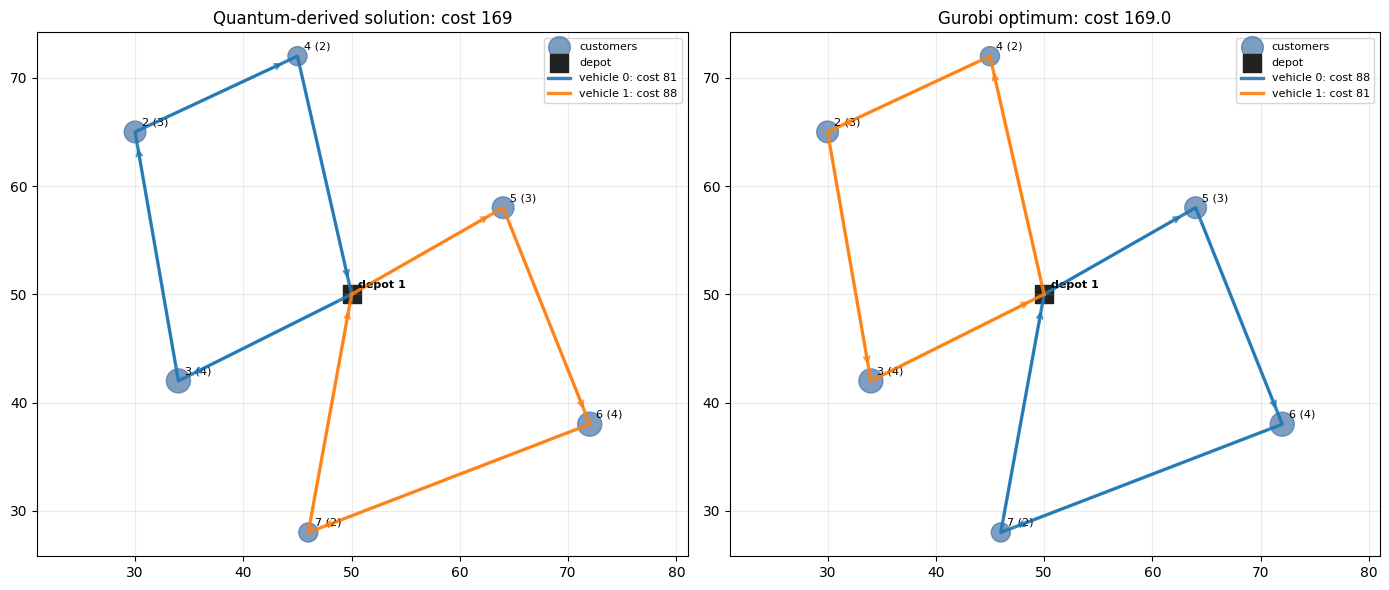

In [65]:
def route_stage_solution_records(route_solutions):
    return [
        {
            'vehicle': solution['route_index'],
            'route': solution['route'],
            'load': solution['load'],
            'cost': solution['cost'],
            'solver': solution['solver'],
        }
        for solution in route_solutions
    ]


def plot_cvrp_route_solution(instance, route_records, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 6))
    _plot_base_instance(instance, ax, title)
    if not instance.get('coords'):
        return ax

    depot = instance['depot']
    color_map = plt.colormaps['tab10']
    for route_index, record in enumerate(route_records):
        route = record['route']
        if not route:
            continue
        color = color_map(route_index % 10)
        full_route = [depot] + route + [depot]
        xs = [instance['coords'][node][0] for node in full_route]
        ys = [instance['coords'][node][1] for node in full_route]
        ax.plot(xs, ys, color=color, linewidth=2.4, alpha=0.9, label=f"vehicle {record['vehicle']}: cost {record['cost']}")

        for start, end in zip(full_route, full_route[1:]):
            start_x, start_y = instance['coords'][start]
            end_x, end_y = instance['coords'][end]
            ax.annotate(
                '',
                xy=(end_x, end_y),
                xytext=(start_x, start_y),
                arrowprops={
                    'arrowstyle': '->',
                    'color': color,
                    'lw': 1.4,
                    'alpha': 0.8,
                    'shrinkA': 12,
                    'shrinkB': 12,
                },
            )
    ax.legend(loc='best', fontsize=8)
    return ax


quantum_solution_records = route_stage_solution_records(route_stage_solutions)
quantum_solution_cost = sum(record['cost'] for record in quantum_solution_records)
classical_solution_cost = classical_solution['objective']
classical_solver_label = 'Gurobi' if classical_solution['solver'] == 'gurobi' else 'Exact enumeration'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_cvrp_route_solution(
    instance,
    quantum_solution_records,
    f"Quantum-derived solution: cost {quantum_solution_cost}",
    ax=axes[0],
)
plot_cvrp_route_solution(
    instance,
    classical_solution['routes'],
    f"{classical_solver_label} optimum: cost {classical_solution_cost}",
    ax=axes[1],
)
fig.tight_layout()
plt.show()
